In [1]:
import numpy as np
import matplotlib.pyplot as plt

### Part a

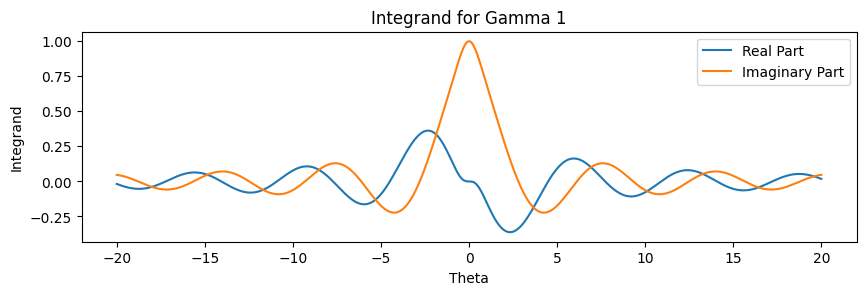

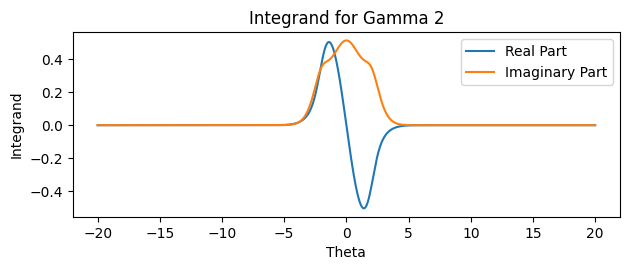

In [2]:
# Define the parameterizations z1(theta) and z2(theta)
def z1(theta):
    return 1j * theta

def z2(theta):
    return (0.2618 - 0.2387 * theta**2) + 0.5j * theta

# Define the integrand f(z) = exp(z)
def integrand(z):
    return np.exp(z)/(z + 1)

# Define the derivatives of z1(theta) and z2(theta) with respect to theta
def z1_prime(theta):
    return 1j

def z2_prime(theta):
    return -2 * 0.2387 * theta + 0.5j

# Define the range of theta values
theta_values = np.linspace(-20, 20, 1000)

# Compute the integrands for gamma 1 and gamma 2
integrand_gamma1_real = np.real(integrand(z1(theta_values))) * np.real(z1_prime(theta_values)) - np.imag(integrand(z1(theta_values))) * np.imag(z1_prime(theta_values))
integrand_gamma1_imag = np.real(integrand(z1(theta_values))) * np.imag(z1_prime(theta_values)) + np.imag(integrand(z1(theta_values))) * np.real(z1_prime(theta_values))

integrand_gamma2_real = np.real(integrand(z2(theta_values))) * np.real(z2_prime(theta_values)) - np.imag(integrand(z2(theta_values))) * np.imag(z2_prime(theta_values))
integrand_gamma2_imag = np.real(integrand(z2(theta_values))) * np.imag(z2_prime(theta_values)) + np.imag(integrand(z2(theta_values))) * np.real(z2_prime(theta_values))

# Plot the real and imaginary parts of the integrands
plt.figure(figsize=(10, 6))

plt.subplot(2, 1, 1)
plt.plot(theta_values, integrand_gamma1_real, label='Real Part')
plt.plot(theta_values, integrand_gamma1_imag, label='Imaginary Part')
plt.title('Integrand for Gamma 1')
plt.xlabel('Theta')
plt.ylabel('Integrand')
plt.legend()
plt.show()


plt.subplot(2, 1, 2)
plt.plot(theta_values, integrand_gamma2_real, label='Real Part')
plt.plot(theta_values, integrand_gamma2_imag, label='Imaginary Part')
plt.title('Integrand for Gamma 2')
plt.xlabel('Theta')
plt.ylabel('Integrand')
plt.legend()

plt.tight_layout()
plt.show()


### Part (b)

In [3]:
# Define a function to check if the modulus of the integrand at +/-M is less than 10^-8
def check_modulus(M):
    return np.abs(integrand(z1(M)) * z1_prime(M)) < 1e-8

# Guess and check for values of M
M_values = np.arange(1, 10000)  # Range of M values to try

for M in M_values:
    mod1_pos = check_modulus(M)
    if mod1_pos:
        break

print("Value of M for gamma 1:", M)

Value of M for gamma 1: 9999


In [4]:
# Define a function to check if the modulus of the integrand at +/-M is less than 10^-8
def check_modulus(M):
    return abs(integrand(z2(M)) * z2_prime(M)) < 1e-8, abs(integrand(z2(-M)) * z2_prime(-M)) < 1e-8

# Guess and check for values of M
M_values = np.linspace(1, 1000, 1000)  # Range of M values to try

for M in M_values:
    M = int(M)
    mod2_pos, mod2_neg = check_modulus(M)
    if mod2_pos and mod2_neg:
        break

print("Value of M for gamma 2:", M)

Value of M for gamma 2: 9


### Part (c)

In [5]:
# exact solutions
I1 = 2 * np.pi * np.exp(-1) * 1j
I2 = 2 * np.pi * np.exp(-1) * 1j
I_abs = np.abs(I1)
print("Absolute value of integrands: ", I_abs)

Absolute value of integrands:  2.3114546995818435


In [6]:
# Define the left-hand N-point quadrature rule function
def left_hand_quadrature(f, g, M, N):
    delta_omega = 2 * M / N
    integral_approx = 0.0
    for j in range(1,N):
        omega_j = - M + (j-1) * delta_omega
        integral_approx = integral_approx + f(g(omega_j))
    return integral_approx * delta_omega


### Convergence with N

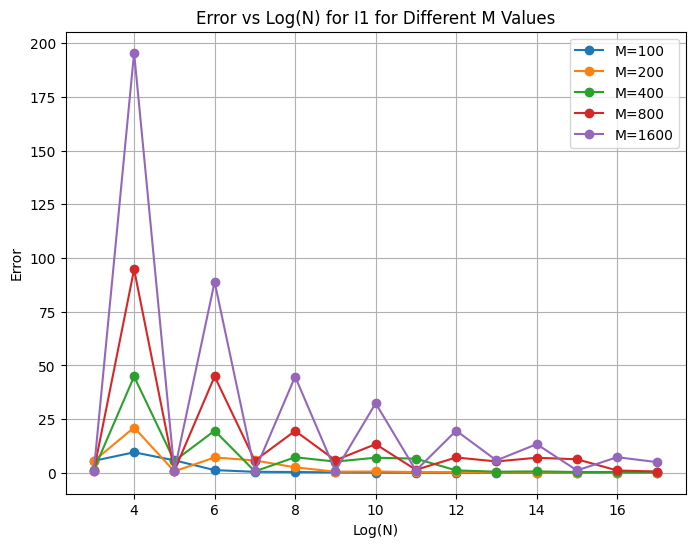

In [7]:
# Define the range of N and M values for convergence studies
N_values_exponent = [3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17]
M_values = [100, 200, 400, 800, 1600]

# Initialize a dictionary to store errors for each N value
errors_N = {}

# Perform convergence study for each N value
for i in N_values_exponent:
    N = i ** 2
    errors_M = []
    
    # Perform convergence study for each M value
    for M in M_values:
        domega = 2 * M / N
        I = left_hand_quadrature(integrand, z1, M, N)
        error = np.abs(I - I_abs)
        errors_M.append(error)
    
    # Store errors for this N value
    errors_N[i] = errors_M

# Plot the error vs N graph for each M value
plt.figure(figsize=(8, 6))
for j, M in enumerate(M_values):
    plt.plot(N_values_exponent, [errors_N[i][j] for i in N_values_exponent], marker='o', label=f'M={M}')
plt.xlabel('Log(N)')
plt.ylabel('Error')
plt.title('Error vs Log(N) for I1 for Different M Values')
plt.legend()
plt.grid(True)
plt.show()


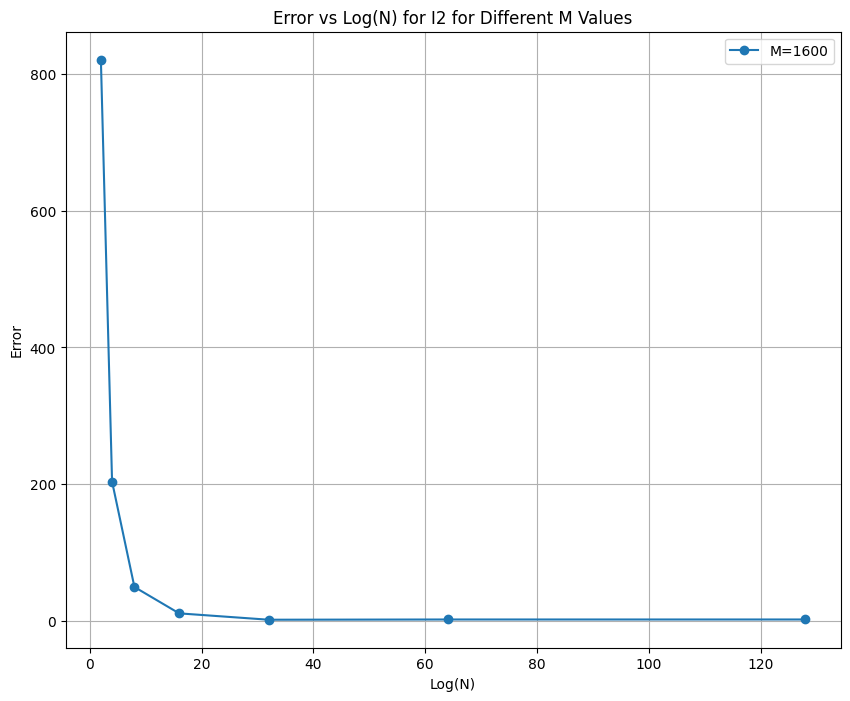

In [8]:
# convergence study of N for I2
M_values = [1600]
N_values_exponent = [2, 4, 8, 16, 32, 64, 128]
errors_N = {}

for i in N_values_exponent:
    N = i ** 2
    errors_M = []
    for M in M_values:
        domega = 2 * M / N
        I = left_hand_quadrature(integrand, z2, M, N)
        error = np.abs(I - I_abs)
        errors_M.append(error)
    errors_N[i] = errors_M

# Plot the error vs N graph for each M value
plt.figure(figsize=(10, 8))
for j, M in enumerate(M_values):
    plt.plot(N_values_exponent, [errors_N[i][j] for i in N_values_exponent], marker='o', label=f'M={M}')
plt.xlabel('Log(N)')
plt.ylabel('Error')
plt.title('Error vs Log(N) for I2 for Different M Values')
plt.legend()
plt.grid(True)
plt.show()
